In [1]:
# Cell: imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

In [7]:
# Cell: load cleaned data 
casualty_clean = pd.read_parquet("data/processed/casualties.parquet")
collision_clean = pd.read_parquet("data/processed/collisions.parquet")
vehicle_clean  = pd.read_parquet("data/processed/vehicles.parquet")

In [8]:
# Cell: overview
def table_overview(df, name):
    total_cells = df.shape[0] * df.shape[1]
    return {
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "total_missing_cells": int(df.isna().sum().sum()),
        "missing_share_%": round(df.isna().sum().sum() / total_cells * 100, 2),
        "fully_populated_cols": int((df.isna().sum() == 0).sum()),
        "all_null_cols": int((df.isna().sum() == len(df)).sum()),
    }

overview = pd.DataFrame([
    table_overview(casualty_clean, "casualty"),
    table_overview(collision_clean, "collision"),
    table_overview(vehicle_clean, "vehicle"),
])
overview

,table,rows,columns,total_missing_cells,missing_share_%,fully_populated_cols,all_null_cols
0,casualty,545250,16,88487,1.01,7,0
1,collision,493271,22,560296,5.16,11,1
2,vehicle,937265,22,2570815,12.47,5,0


In [9]:
# Cell: full missing summary per column
def missing_summary(df, name):
    miss = df.isna().sum()
    pct = (miss / len(df) * 100).round(2)
    out = pd.DataFrame({
        "table": name,
        "column": miss.index,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": miss.values,
        "missing_pct": pct.values,
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    })
    return out.sort_values("missing_pct", ascending=False).reset_index(drop=True)

miss_all = pd.concat([
    missing_summary(casualty_clean, "casualty"),
    missing_summary(collision_clean, "collision"),
    missing_summary(vehicle_clean,  "vehicle"),
], ignore_index=True)

# Top 30 "leakiest" columns across all tables
miss_all.sort_values("missing_pct", ascending=False).head(30)

,table,column,dtype,missing_count,missing_pct,n_unique
16,collision,local_authority_ons_district,str,493271,100.00,0
38,vehicle,journey_purpose_of_driver,float64,626098,66.80,5
39,vehicle,age_of_vehicle,float64,363287,38.76,98
40,vehicle,engine_capacity_cc,float64,234989,25.07,1522
41,vehicle,driver_imd_decile,float64,199518,21.29,10
43,vehicle,age_of_driver,float64,142240,15.18,102
42,vehicle,age_band_of_driver,float64,142240,15.18,11
44,vehicle,sex_of_driver,float64,122370,13.06,2
45,vehicle,vehicle_manoeuvre,float64,91755,9.79,17
46,vehicle,skidding_and_overturning,float64,91490,9.76,6


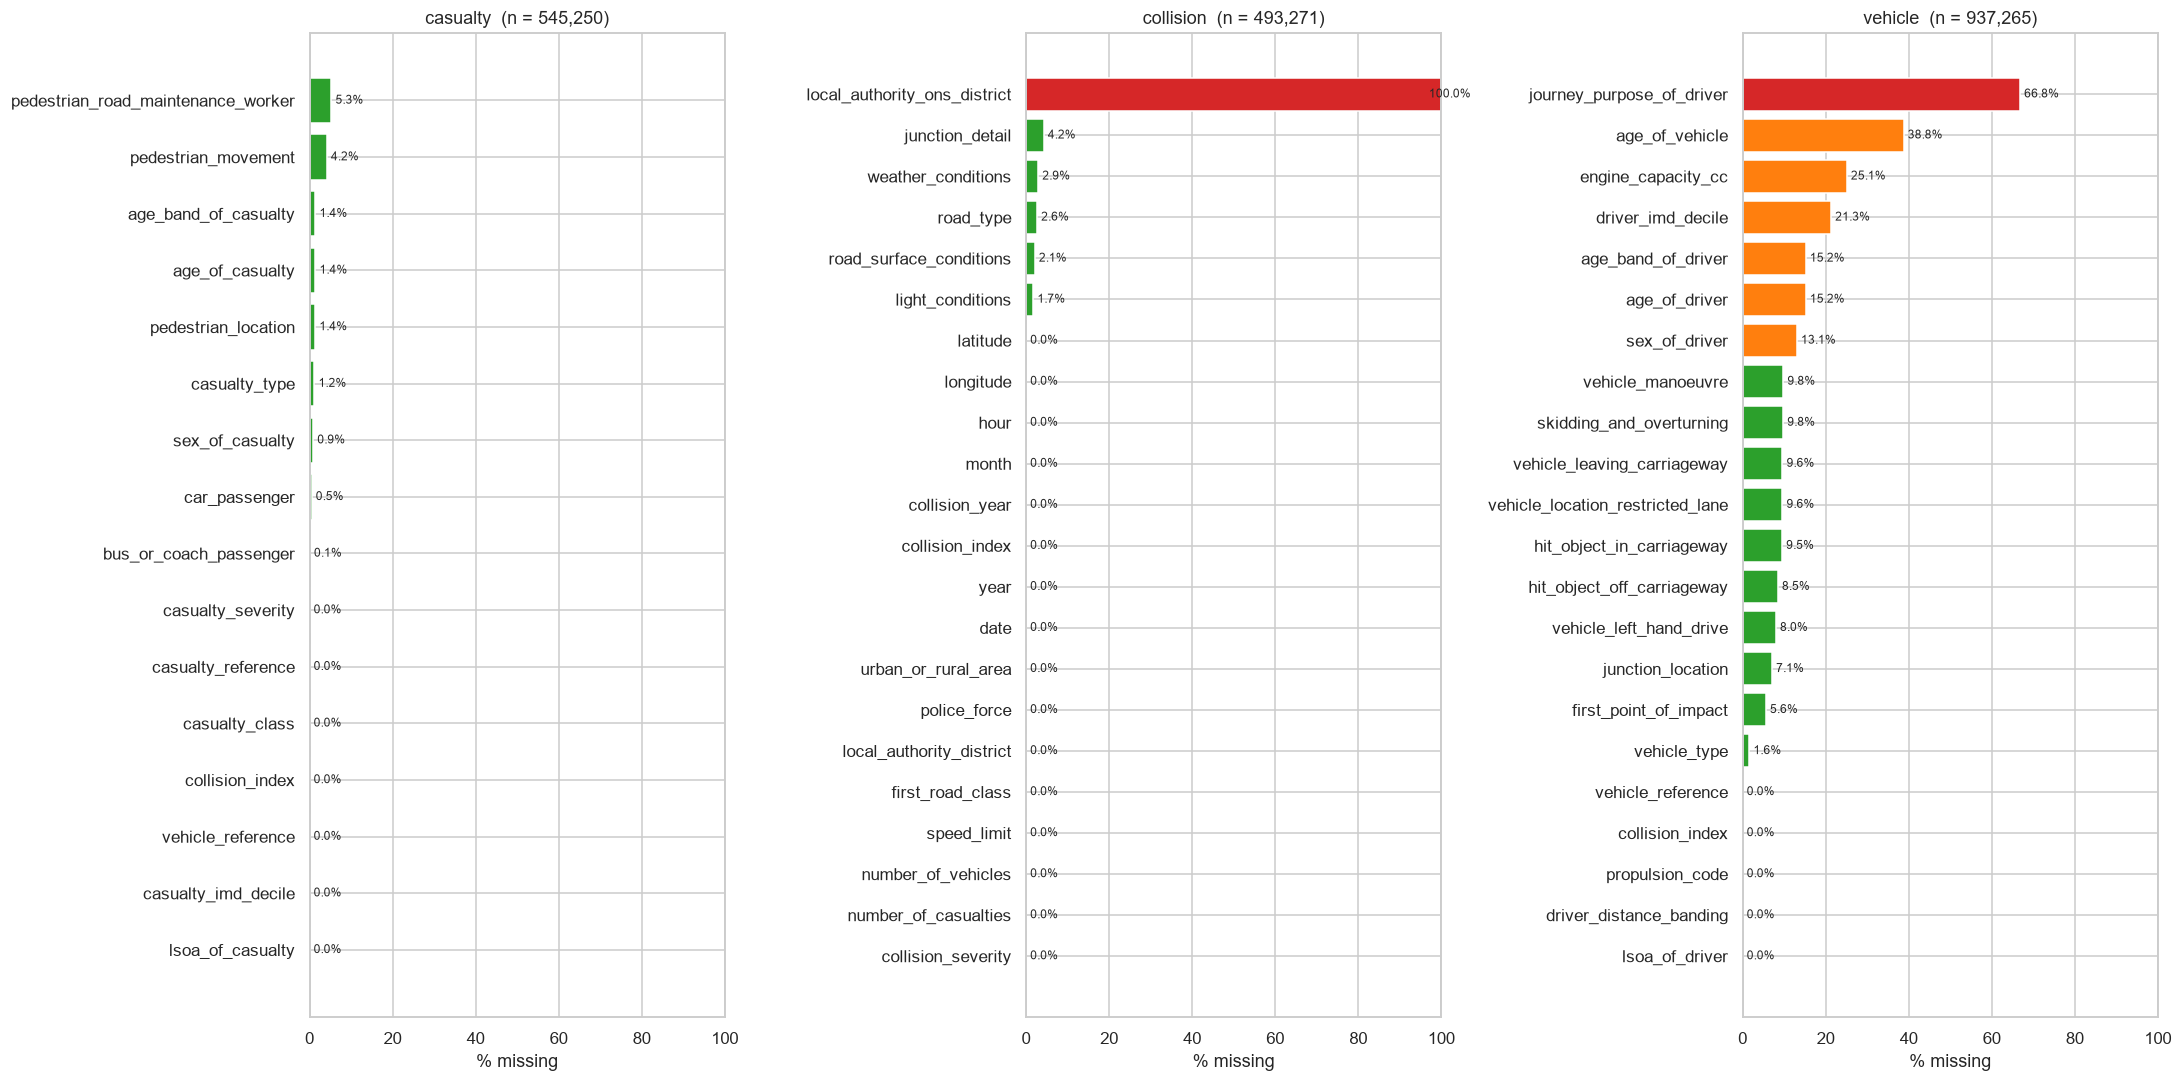

In [10]:
# Cell: missing % bar charts
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for ax, (df, name) in zip(
    axes,
    [(casualty_clean, "casualty"),
     (collision_clean, "collision"),
     (vehicle_clean,  "vehicle")],
):
    summ = missing_summary(df, name)
    colors = [
        "#d62728" if p > 50 else
        "#ff7f0e" if p > 10 else
        "#2ca02c"
        for p in summ["missing_pct"]
    ]
    ax.barh(summ["column"], summ["missing_pct"], color=colors)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_xlabel("% missing")
    ax.set_title(f"{name}  (n = {len(df):,})")
    for i, p in enumerate(summ["missing_pct"]):
        ax.text(min(p + 1, 97), i, f"{p:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

Green — <10% missing values, orange — 10–50%, red — >50%.

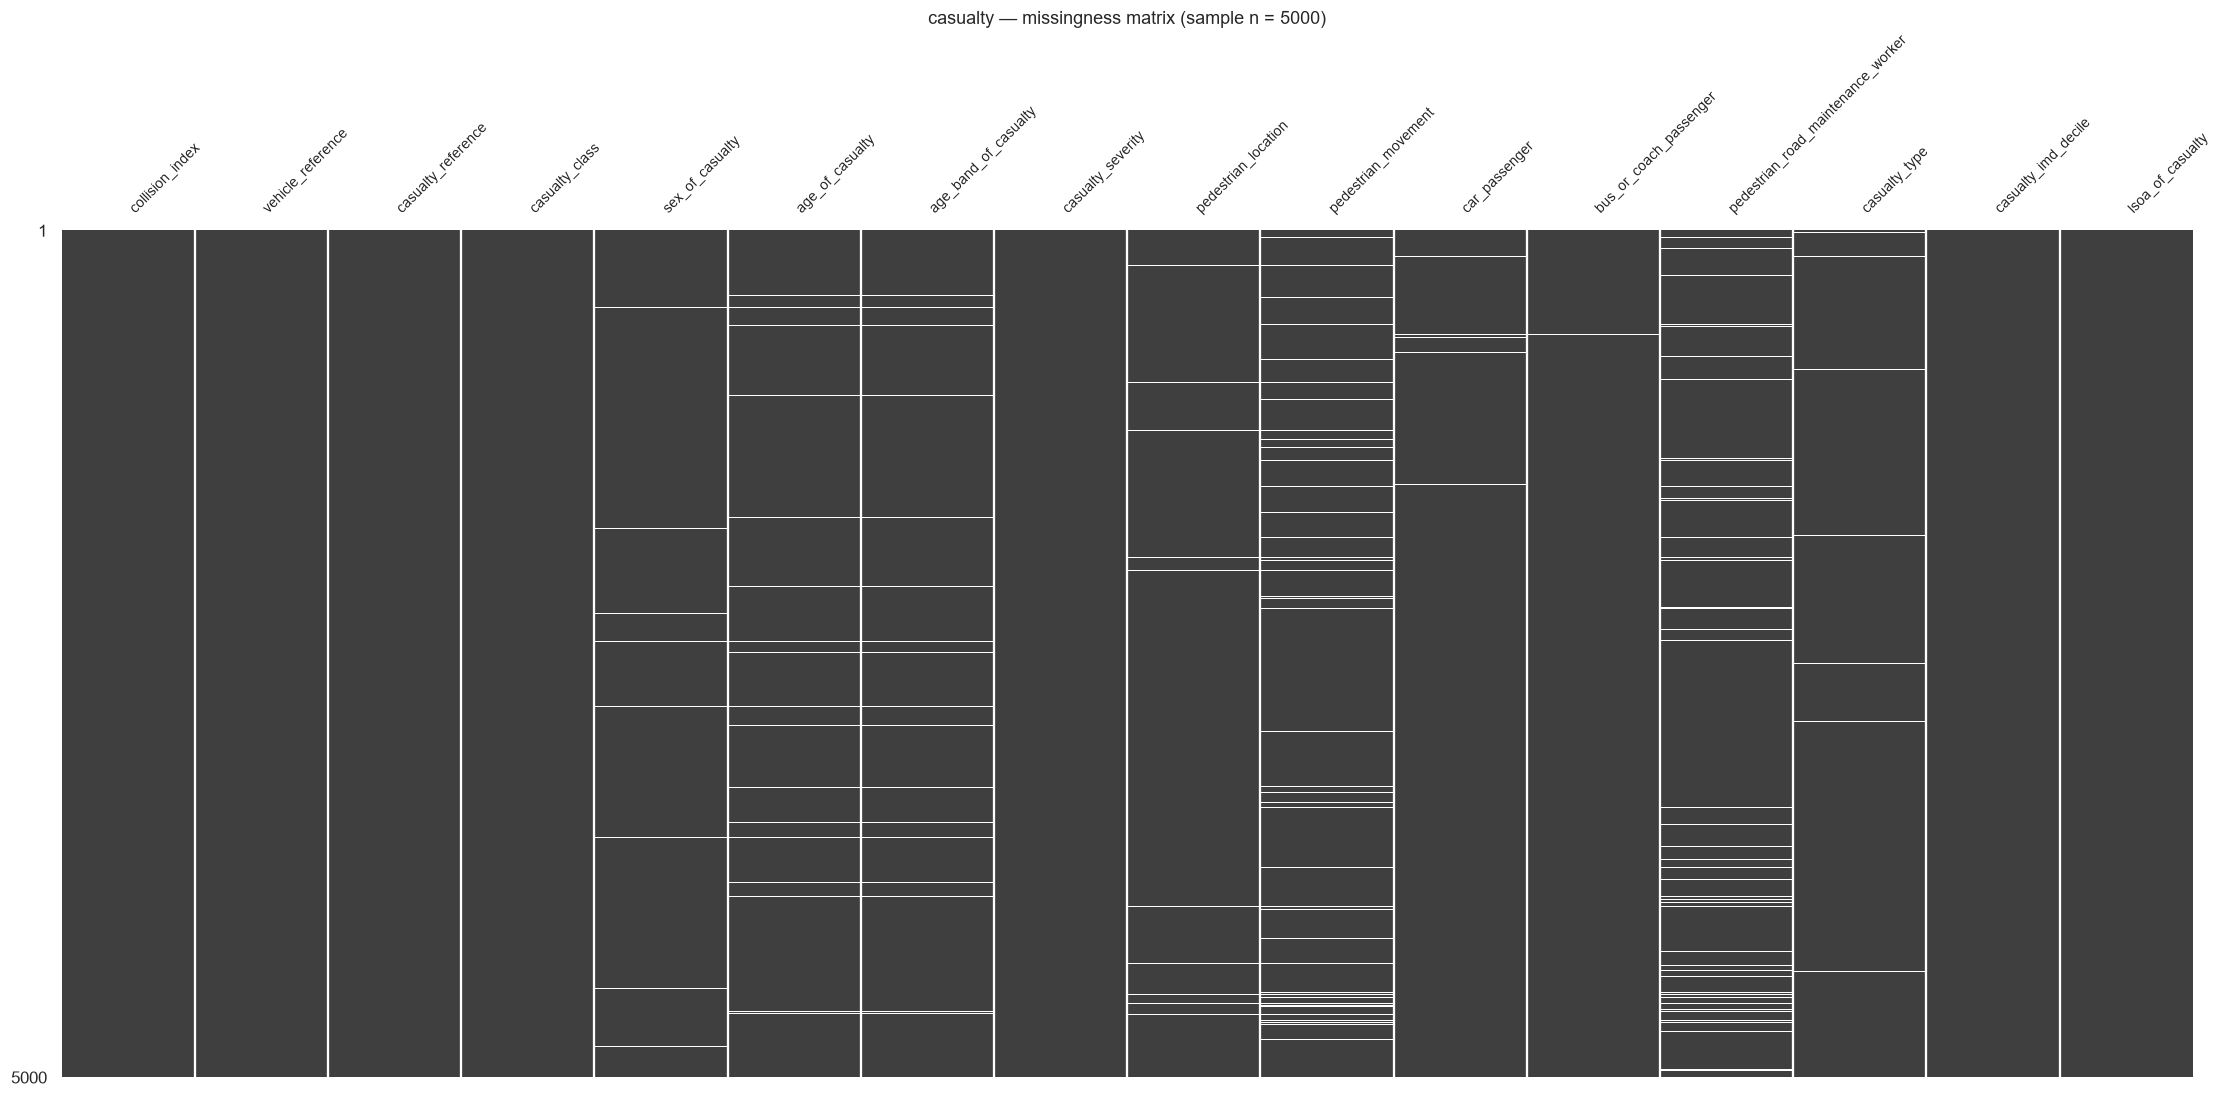

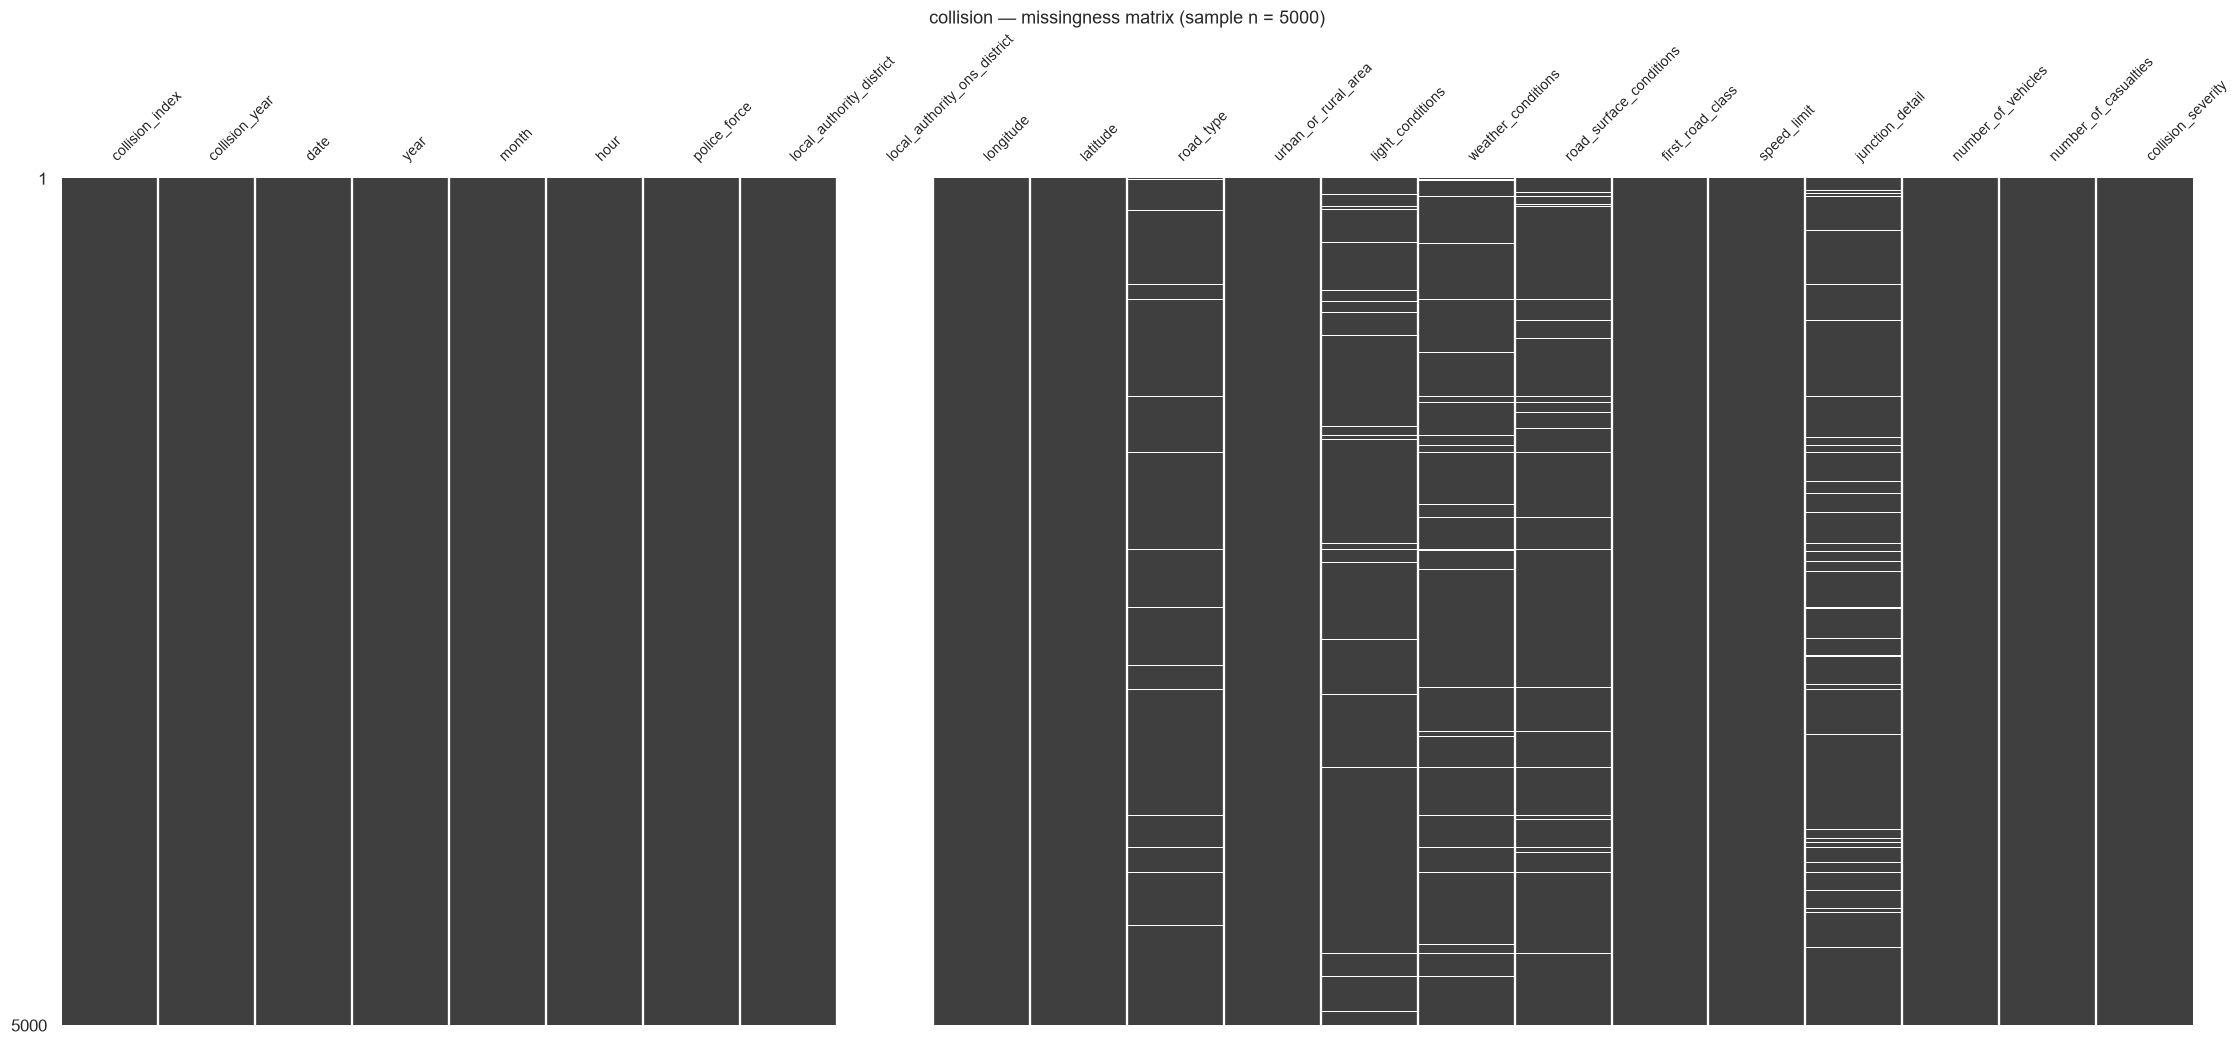

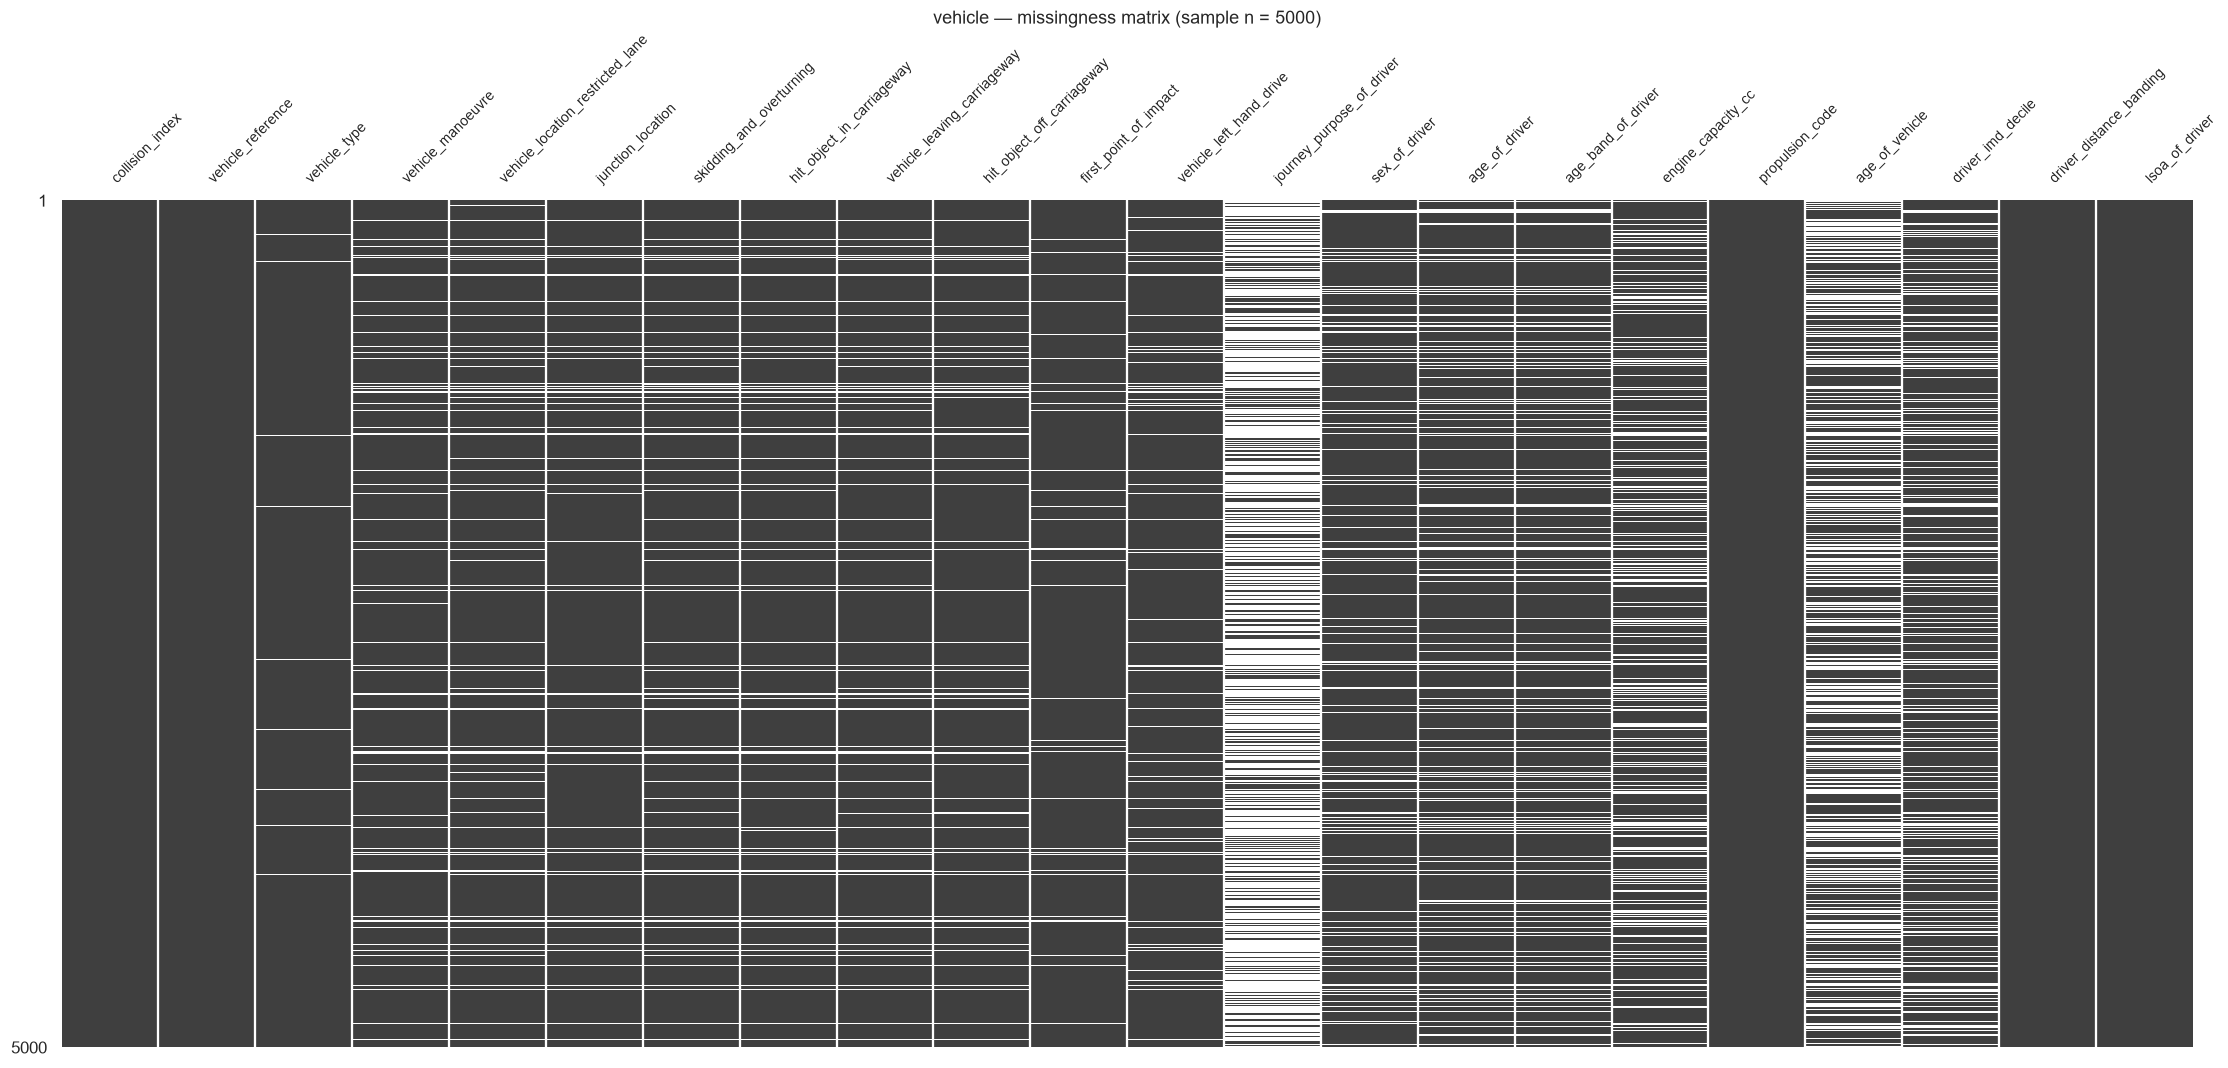

In [11]:
# Cell: missingness matrix 
SAMPLE_N = 5000

for df, name in [
    (casualty_clean, "casualty"),
    (collision_clean, "collision"),
    (vehicle_clean,  "vehicle"),
]:
    sample = df.sample(min(SAMPLE_N, len(df)), random_state=42)
    msno.matrix(sample, sparkline=False, fontsize=9)
    plt.title(f"{name} — missingness matrix (sample n = {len(sample)})")
    plt.show()

It shows which fields "disappear together", for example, `age_of_driver` and `age_band_of_driver`.

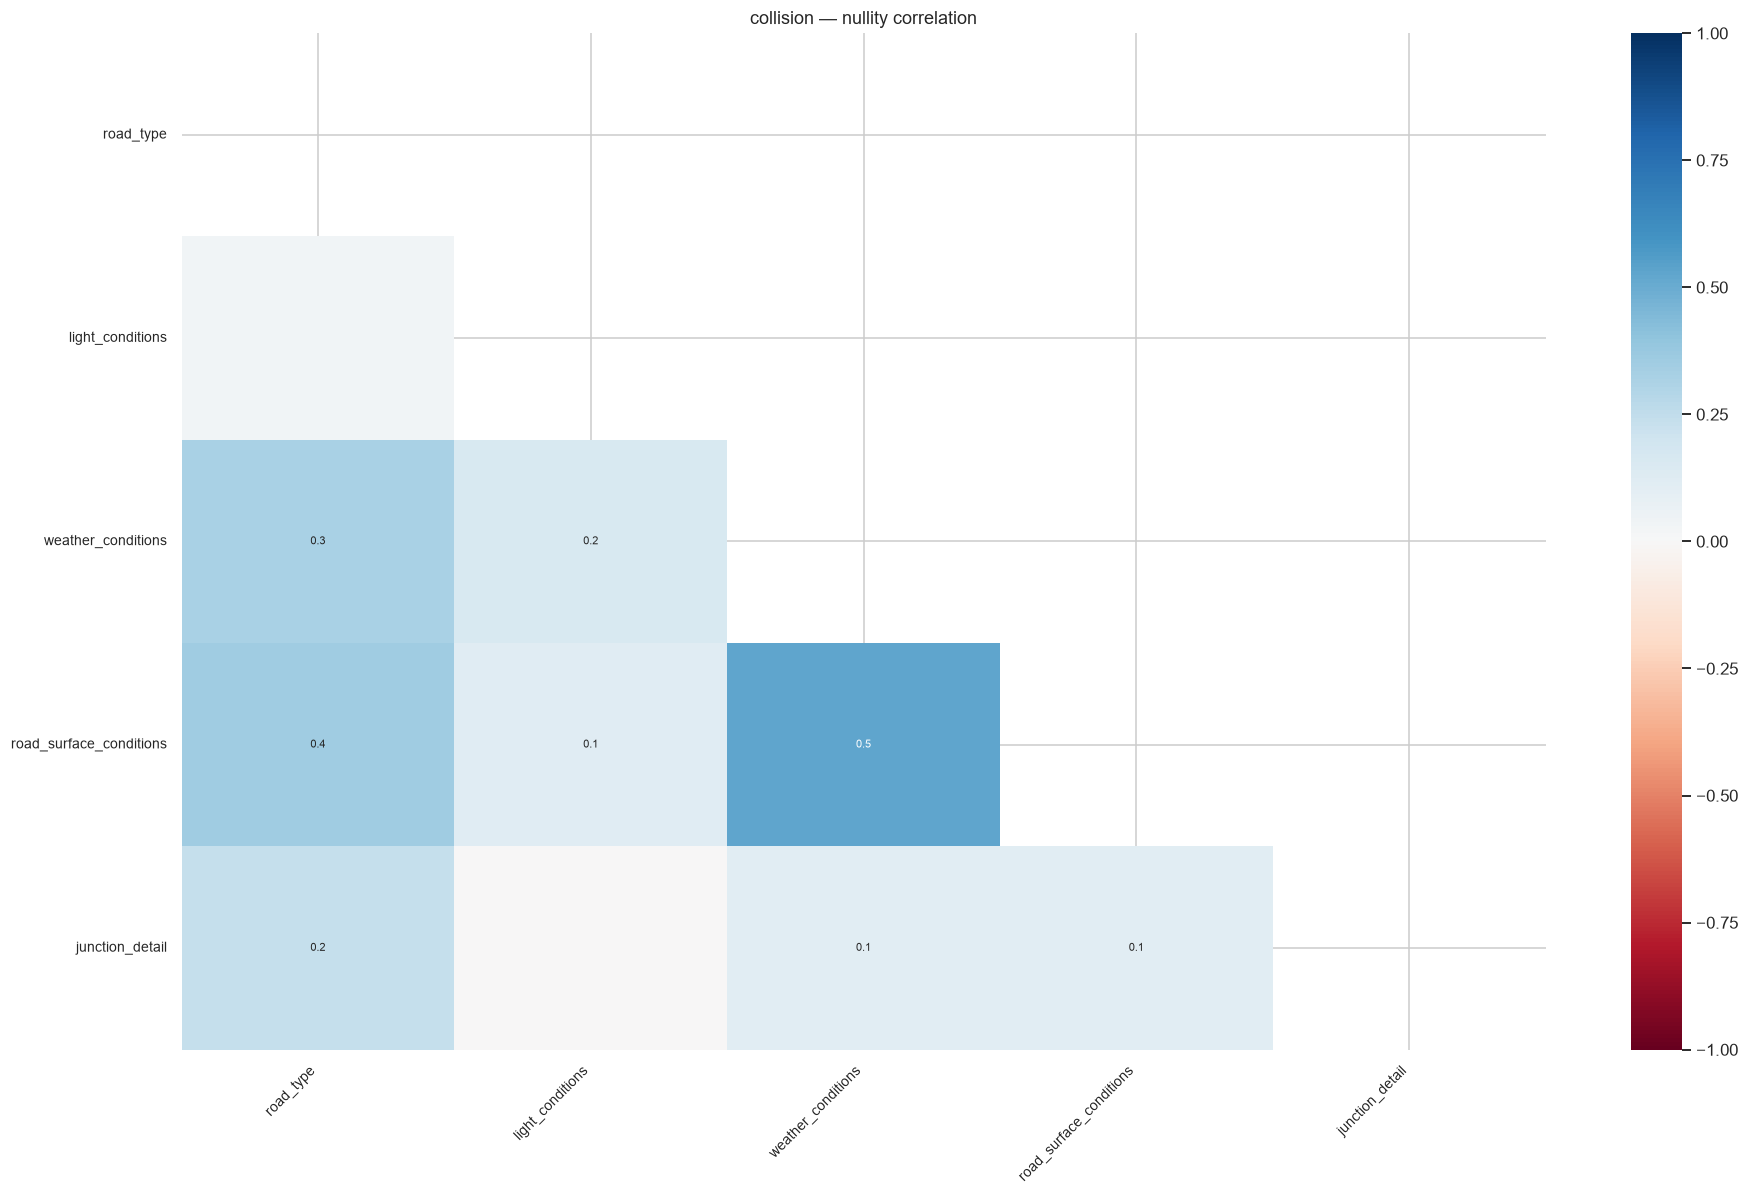

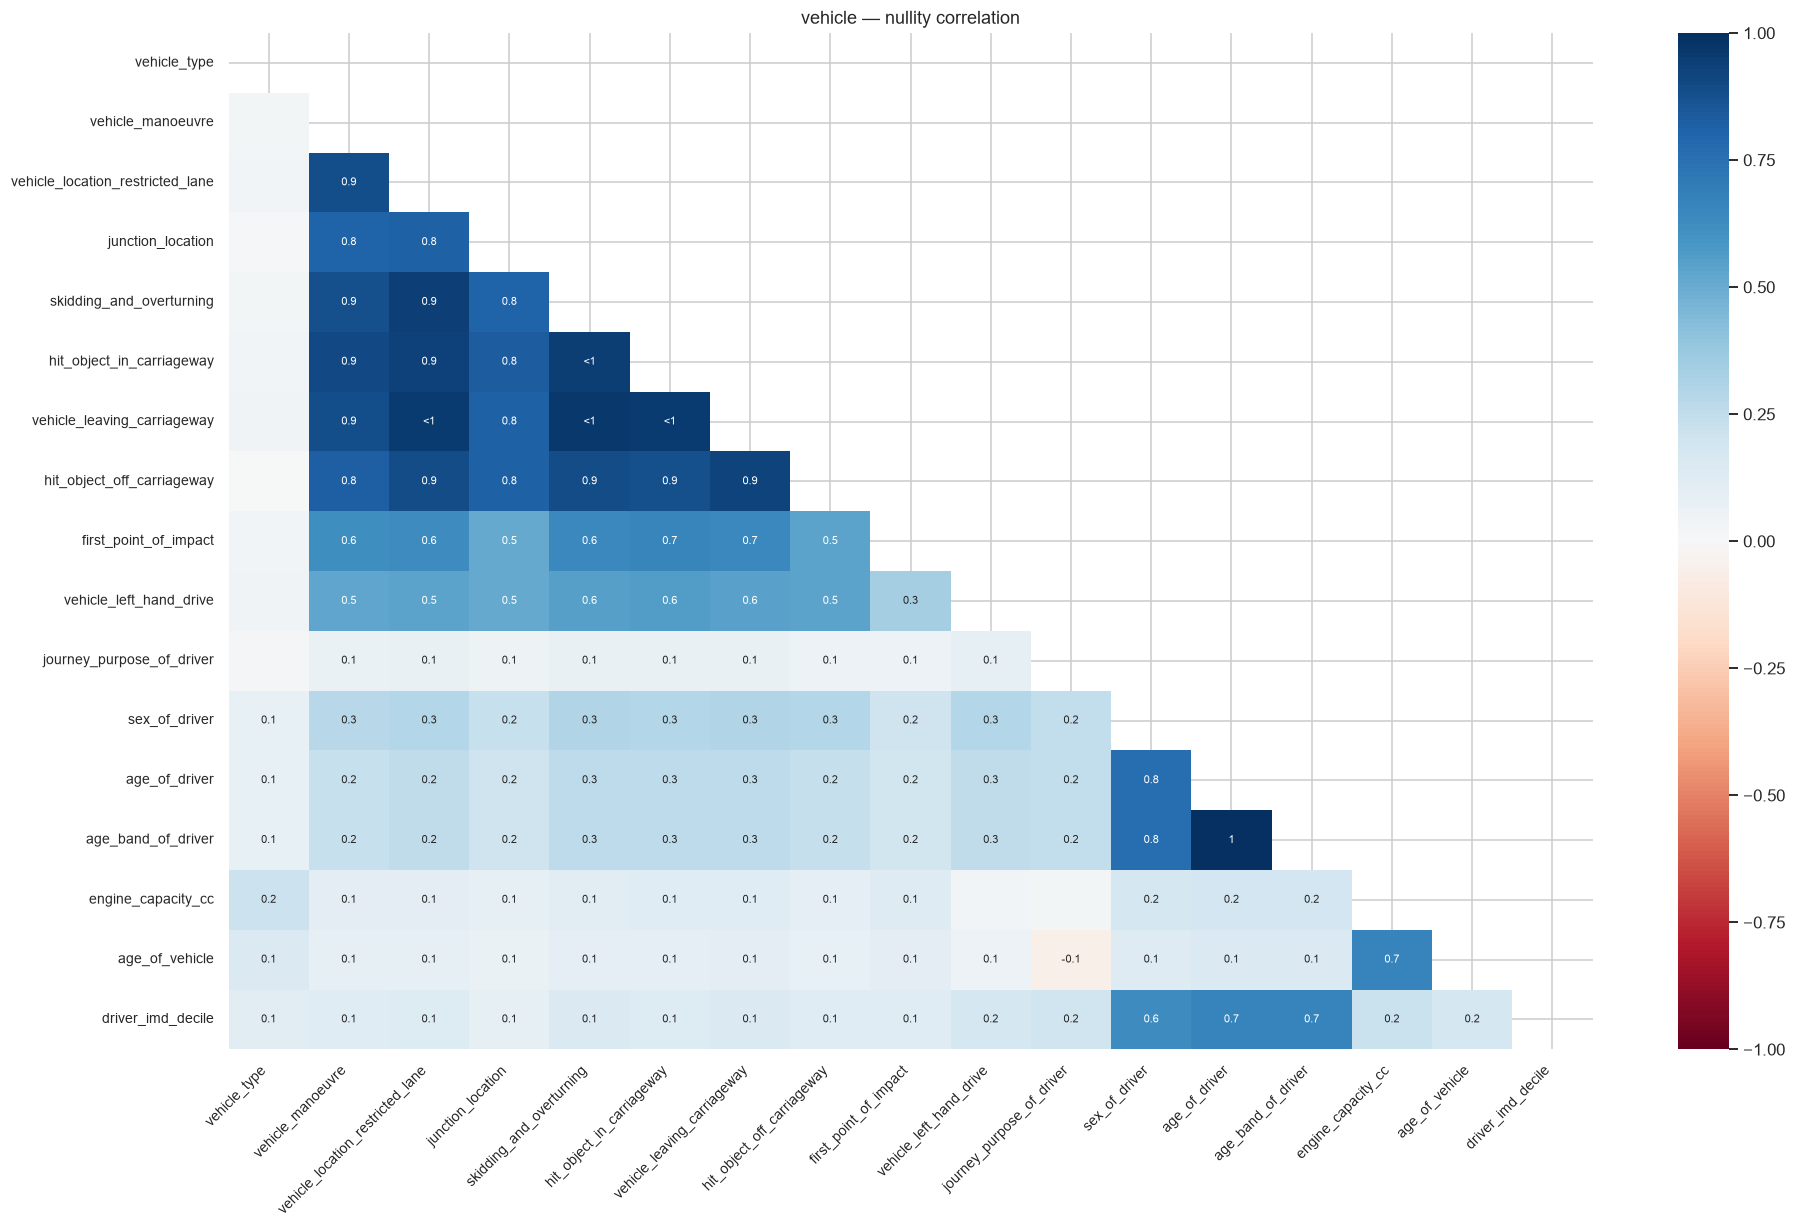

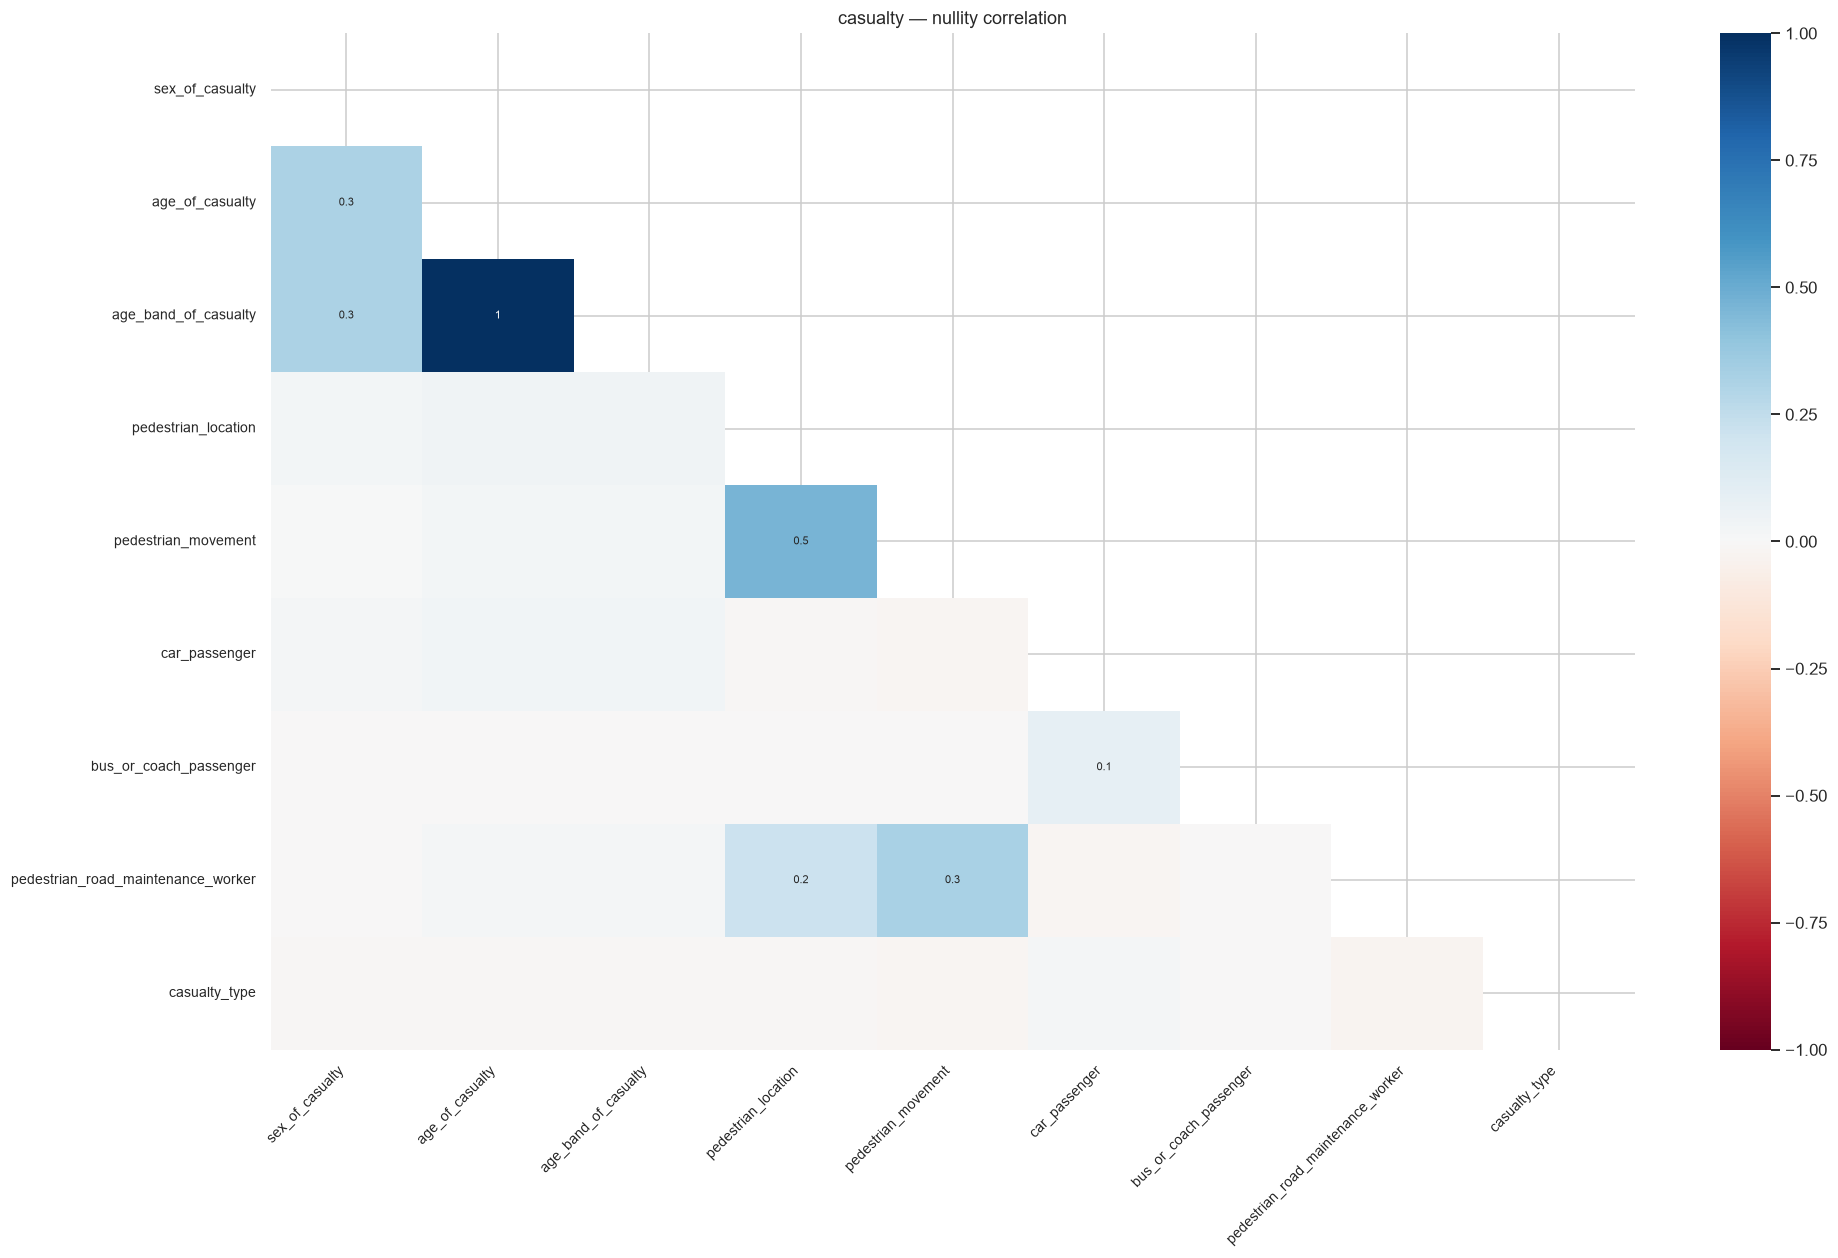

In [15]:
# Cell: nullity heatmap
for df, name in [
    (collision_clean, "collision"),
    (vehicle_clean,  "vehicle"),
    (casualty_clean, "casualty"),
]:
    sample = df.sample(min(SAMPLE_N, len(df)), random_state=42)
    msno.heatmap(sample, fontsize=9)
    plt.title(f"{name} — nullity correlation")
    plt.show()

In [14]:
# Cell: automated findings
def worst_columns(df, name, top=5):
    summ = missing_summary(df, name)
    return summ.head(top)[["column", "missing_pct"]]

for df, name in [(casualty_clean, "casualty"),
                 (collision_clean, "collision"),
                 (vehicle_clean,  "vehicle")]:
    print(f"\n=== {name} — top 5 for missing data ===")
    print(worst_columns(df, name).to_string(index=False))


=== casualty — top 5 for missing data ===
                            column  missing_pct
pedestrian_road_maintenance_worker         5.26
               pedestrian_movement         4.16
              age_band_of_casualty         1.40
                   age_of_casualty         1.40
               pedestrian_location         1.36

=== collision — top 5 for missing data ===
                      column  missing_pct
local_authority_ons_district       100.00
             junction_detail         4.24
          weather_conditions         2.90
                   road_type         2.63
     road_surface_conditions         2.08

=== vehicle — top 5 for missing data ===
                   column  missing_pct
journey_purpose_of_driver        66.80
           age_of_vehicle        38.76
       engine_capacity_cc        25.07
        driver_imd_decile        21.29
       age_band_of_driver        15.18
